# Logic Tensor Networks para Raciocínio Espacial em Cenas CLEVR-like

**Inteligência Artificial — IEC034 / ICC265 (2026/1) · Prof. Edjard Mota · UFAM**
**Autor:** _[seu nome — matrícula]_

Este notebook implementa um agente **neuro-simbólico (NeSy)** que aprende a raciocinar
sobre relações espaciais em um ambiente CLEVR simplificado, usando **Logic Tensor
Networks** (LTNtorch). Em vez de processar imagens, cada objeto é um **vetor de
características** de 11 dimensões; predicados são redes neurais e o conhecimento de
domínio é codificado como **axiomas de lógica de primeira ordem diferenciável**.

O notebook cobre as Tarefas 1–4 do enunciado e a entrega final (experimento de 5
execuções com satAgg, acurácia, precisão, recall e F1), além das explicações de
raciocínio (ponto extra).

## 0. Fundamentação: NeSy, LTN e *grounding*

**IA Neuro-simbólica (NeSy)** combina o aprendizado sub-simbólico das redes neurais
com a interpretabilidade e o rigor da lógica simbólica. **Logic Tensor Networks (LTN)**
é uma das realizações dessa ideia: faz a ponte entre a Lógica de Primeira Ordem (FOL)
e o aprendizado profundo por meio de um mapeamento contínuo chamado **grounding** $\mathcal{G}$.

| Símbolo lógico | Elemento LTNtorch | Grounding $\mathcal{G}$ |
|---|---|---|
| Constante $c$ | `ltn.Constant` | tensor real (ex.: vetor do objeto) |
| Variável $x$ | `ltn.Variable` | sequência de indivíduos |
| Predicado $P$ | `ltn.Predicate` | rede $\mathbb{R}^n \to [0,1]$ (verdade fuzzy) |
| Função $f$ | `ltn.Function` | camada $\mathbb{R}^n \to \mathbb{R}^m$ |

**Lógica fuzzy diferenciável** (assinatura idêntica à do notebook de referência
`XAI_In_LTN.ipynb` do Prof. Mota):
negação $\mathcal{G}(\neg p)=1-p$ (`NotStandard`); conjunção $\mathcal{G}(p\wedge q)=p\cdot q$
(`AndProd`, T-norma do produto); disjunção $\mathcal{G}(p\vee q)=p+q-p\cdot q$ (`OrProbSum`);
implicação de Reichenbach $\mathcal{G}(p\to q)=1-p+p\cdot q$ (`ImpliesReichenbach`).
Quantificadores usam médias-$p$ generalizadas: $\forall$ via `AggregPMeanError(p=2)`
(pune qualquer desvio da verdade absoluta) e $\exists$ via `AggregPMean(p=2)`. O nível
de satisfação global da base de conhecimento é o `SatAgg`, e o treino **maximiza** a
satisfatibilidade: $\text{loss} = 1 - \text{SatAgg}(\mathcal{K})$.

**Por que apenas axiomas estruturais não bastam (a solução degenerada).**
No exemplo mínimo de referência, treinando *somente* o axioma de assimetria
$\forall x,y\,(\text{LeftOf}(x,y)\to\neg\text{LeftOf}(y,x))$, a rede converge para
$\text{LeftOf}\equiv 0$ em todos os pares — o que satisfaz a assimetria trivialmente
($0\to\neg 0 = 0\to 1 = \text{verdadeiro}$) mas é **geometricamente errado**. Por isso,
nossa base de conhecimento combina **fatos de *grounding*** (supervisão a partir das
coordenadas/atributos) **com os axiomas estruturais**: os fatos ancoram a semântica real
e os axiomas atuam como regularizadores lógicos.

**Horizonte teórico (fibring).** O artigo *From Neural Networks to Logical Theories*
(El Harzli, d'Avila Garcez et al., ICLR 2026) formaliza a correspondência entre
*fibring* de redes e *fibring* de lógicas modais, permitindo caracterizar a
expressividade lógica de arquiteturas profundas — a contrapartida *bottom-up* da
abordagem *top-down* do LTN usada aqui.

In [1]:
# Bibliotecas e assinatura lógica
import numpy as np
import torch
import torch.nn as nn
import ltn
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time, json
from IPython.display import Image
torch.set_num_threads(4)
%matplotlib inline

## 1. Tarefa 1 — Geração da cena e taxonomia dos objetos

Cada objeto é um vetor de **11 dimensões**:

| índice | conteúdo |
|---|---|
| `[0,1]` | posição $x,y$ normalizada em $[0,1]$ |
| `[2,3,4]` | cor *one-hot* (Red, Green, Blue) |
| `[5,6,7,8,9]` | forma *one-hot* (Circle, Square, Cylinder, Cone, Triangle) |
| `[10]` | tamanho (0.0 = small, 1.0 = big) |

Geramos 25 objetos aleatórios e plotamos a cena no estilo do tutorial CLEVR-like
(cor = cor do objeto, marcador = forma, tamanho do marcador = small/big, rótulo = índice).

In [2]:
SHAPES = ['Circle', 'Square', 'Cylinder', 'Cone', 'Triangle']
COLORS = ['Red', 'Green', 'Blue']
COLOR_RGB = {'Red': '#e8413a', 'Green': '#2aa84a', 'Blue': '#3b6fe0'}
SHAPE_MARKER = {'Circle': 'o', 'Square': 's', 'Cylinder': 'H', 'Cone': 'v', 'Triangle': '^'}

# Object vector (length 11):
#  [0,1]  -> x, y   (normalized 0..1)
#  [2,3,4]-> color one-hot (Red, Green, Blue)
#  [5..9] -> shape one-hot (Circle, Square, Cylinder, Cone, Triangle)
#  [10]   -> size (0.0 small, 1.0 big)

def generate_scene(n=25, seed=None):
    rng = np.random.default_rng(seed)
    objs = np.zeros((n, 11), dtype=np.float32)
    objs[:, 0:2] = rng.random((n, 2))                       # positions
    col = rng.integers(0, 3, size=n)                        # color idx
    sh  = rng.integers(0, 5, size=n)                        # shape idx
    objs[np.arange(n), 2 + col] = 1.0
    objs[np.arange(n), 5 + sh] = 1.0
    objs[:, 10] = rng.integers(0, 2, size=n).astype(np.float32)  # size
    return objs

def shape_idx(o):  return int(np.argmax(o[5:10]))
def color_idx(o):  return int(np.argmax(o[2:5]))
def shape_name(o): return SHAPES[shape_idx(o)]
def color_name(o): return COLORS[color_idx(o)]
def is_big(o):     return o[10] >= 0.5

In [3]:
def plot_scene(objs, title='Cena CLEVR-like (gerada aleatoriamente)', path='scene.png'):
    fig, ax = plt.subplots(figsize=(7, 7))
    for i, o in enumerate(objs):
        c = COLOR_RGB[color_name(o)]
        m = SHAPE_MARKER[shape_name(o)]
        s = 380 if is_big(o) else 130
        ax.scatter(o[0], o[1], c=c, marker=m, s=s, edgecolors='black',
                   linewidths=1.0, alpha=0.92, zorder=3)
        ax.annotate(str(i), (o[0], o[1]), fontsize=7, ha='center', va='center',
                    zorder=4, color='white', fontweight='bold')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(title)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)
    # legends
    shape_h = [Line2D([0],[0], marker=SHAPE_MARKER[s], color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=10, label=s) for s in SHAPES]
    color_h = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_RGB[c],
               markeredgecolor='k', markersize=10, label=c) for c in COLORS]
    size_h  = [Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='k',
               markersize=8, label='Small'),
               Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='k',
               markersize=14, label='Big')]
    leg1 = ax.legend(handles=shape_h, title='Forma', loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8)
    leg2 = ax.legend(handles=color_h, title='Cor', loc='upper left', bbox_to_anchor=(1.01, 0.58), fontsize=8)
    ax.add_artist(leg1)
    ax.legend(handles=size_h, title='Tamanho', loc='upper left', bbox_to_anchor=(1.01, 0.30), fontsize=8)
    ax.add_artist(leg2)
    plt.tight_layout()
    plt.savefig(path, dpi=110, bbox_inches='tight')
    plt.close()
    return path

Distribuição de formas: {'Circle': 5, 'Square': 5, 'Cylinder': 7, 'Cone': 4, 'Triangle': 4}
Distribuição de cores : {'Red': 7, 'Green': 9, 'Blue': 9}
Objetos grandes: 12 / 25


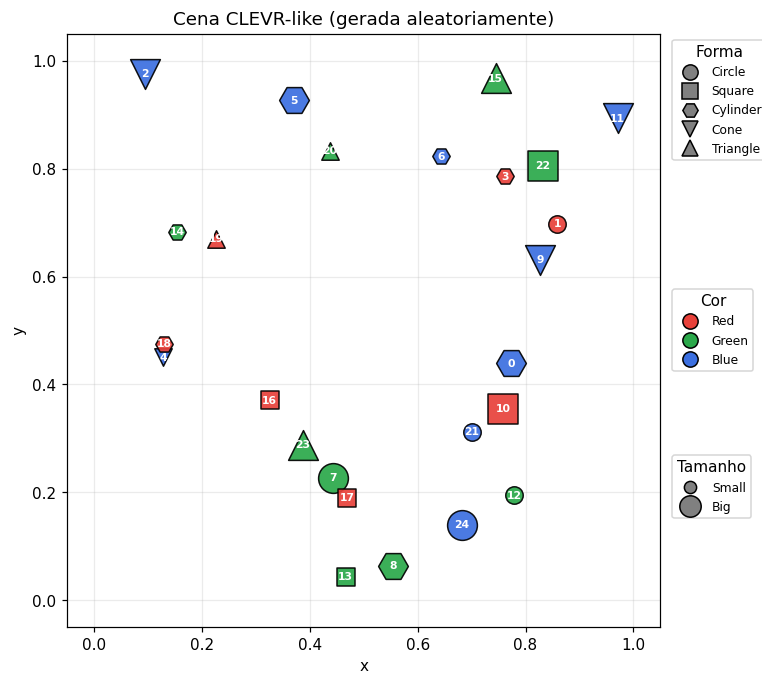

In [4]:
np.random.seed(7)
objs = generate_scene(25, seed=42)
plot_scene(objs, path='scene.png')
print('Distribuição de formas:', {s: sum(shape_name(o) == s for o in objs) for s in SHAPES})
print('Distribuição de cores :', {c: sum(color_name(o) == c for o in objs) for c in COLORS})
print('Objetos grandes:', int(sum(is_big(o) for o in objs)), '/ 25')
Image('scene.png')

## 2. Predicados neurais e analíticos

**Predicados de atributo (Tarefa 1).** `isCircle`, `isSquare`, `isCylinder`, `isCone`,
`isTriangle` (formas); `isRed`, `isGreen`, `isBlue` (cores); `isSmall`, `isBig` (tamanho).
Cada grupo compartilha **uma única rede** com várias saídas — assim os axiomas de
unicidade e cobertura realmente acoplam os predicados do mesmo grupo.

**Relações espaciais (Tarefas 2 e 3).** `leftOf`, `rightOf`, `below`, `above` são redes
binárias que recebem **dois objetos concatenados** (22-dim), exatamente como o
`LeftOfModel` do notebook de referência (`forward(self, x, y)` → `cat([x,y])` → `sigmoid`).

**Predicados analíticos (sem parâmetros).** `closeTo` usa o núcleo gaussiano sugerido,
$\text{closeTo}(x,y)=e^{-\gamma\lVert x_{pos}-y_{pos}\rVert^2}$; `sameSize` é a igualdade
suave do bit de tamanho; `diff` distingue objetos idênticos (para excluir o próprio
objeto em fórmulas $\forall y$); `horizClose` mede alinhamento horizontal (para `canStack`).

> Sobre $\gamma$: o enunciado sugere coeficiente 2, mas em coordenadas normalizadas isso
> torna quase todo par "próximo". Usamos $\gamma=10$, de modo que `closeTo`>0.5 corresponde
> a distância $\lesssim 0.26$ — uma noção discriminativa de proximidade no quadrado unitário.

In [5]:
# ---------- Connectives / Quantifiers (matching Prof. Mota's slides) ----------
Not    = ltn.Connective(ltn.fuzzy_ops.NotStandard())
And    = ltn.Connective(ltn.fuzzy_ops.AndProd())
Or     = ltn.Connective(ltn.fuzzy_ops.OrProbSum())
Implies= ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
Equiv  = ltn.Connective(ltn.fuzzy_ops.Equiv(and_op=ltn.fuzzy_ops.AndProd(),
                                            implies_op=ltn.fuzzy_ops.ImpliesReichenbach()))
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier='f')
Exists = ltn.Quantifier(ltn.fuzzy_ops.AggregPMean(p=2),      quantifier='e')
SatAgg = ltn.fuzzy_ops.SatAgg()

GAMMA_CLOSE = 10.0   # Gaussian kernel sharpness for closeTo on the unit square
GAMMA_HORIZ = 30.0   # horizontal-alignment sharpness for canStack stability

def and_all(*xs):
    r = xs[0]
    for x in xs[1:]: r = And(r, x)
    return r
def or_all(*xs):
    r = xs[0]
    for x in xs[1:]: r = Or(r, x)
    return r

# ---------------------------- Predicate models --------------------------------
class MultiClassNet(nn.Module):
    """One shared net -> logits over the classes of an attribute group."""
    def __init__(self, in_dim, n_classes, hidden=16):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ELU(),
                                 nn.Linear(hidden, hidden), nn.ELU(),
                                 nn.Linear(hidden, n_classes))
    def forward(self, x): return self.net(x)

class ClassPredicate(nn.Module):
    """Picks one class channel from a shared MultiClassNet and squashes to [0,1]."""
    def __init__(self, net, idx):
        super().__init__(); self.net = net; self.idx = idx; self.sig = nn.Sigmoid()
    def forward(self, x):
        if hasattr(x, 'value'): x = x.value
        return self.sig(self.net(x)[:, self.idx])

class RelNet(nn.Module):
    """Binary spatial relation over two concatenated object vectors (22-dim)."""
    def __init__(self, in_dim=22, hidden=16):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ELU(),
                                 nn.Linear(hidden, hidden), nn.ELU(),
                                 nn.Linear(hidden, 1))
        self.sig = nn.Sigmoid()
    def forward(self, x, y):
        if hasattr(x, 'value'): x = x.value
        if hasattr(y, 'value'): y = y.value
        z = torch.cat([x, y], dim=-1)
        return self.sig(self.net(z)).squeeze(-1)

In [6]:
def build_predicates():
    shape_net = MultiClassNet(11, 5)
    color_net = MultiClassNet(11, 3)
    size_net  = MultiClassNet(11, 2)
    P = {}
    for i, s in enumerate(SHAPES): P['is'+s]  = ltn.Predicate(ClassPredicate(shape_net, i))
    for i, c in enumerate(COLORS): P['is'+c]  = ltn.Predicate(ClassPredicate(color_net, i))
    P['isSmall'] = ltn.Predicate(ClassPredicate(size_net, 0))
    P['isBig']   = ltn.Predicate(ClassPredicate(size_net, 1))
    P['leftOf']  = ltn.Predicate(RelNet())
    P['rightOf'] = ltn.Predicate(RelNet())
    P['below']   = ltn.Predicate(RelNet())
    P['above']   = ltn.Predicate(RelNet())
    nets = {'shape': shape_net, 'color': color_net, 'size': size_net}
    # analytical (non-trainable) predicates
    P['closeTo']  = ltn.Predicate(func=lambda x, y: torch.exp(
        -GAMMA_CLOSE * torch.sum((x[:, :2] - y[:, :2]) ** 2, dim=-1)))
    P['sameSize'] = ltn.Predicate(func=lambda x, y: 1.0 - torch.abs(x[:, 10] - y[:, 10]))
    P['diff']     = ltn.Predicate(func=lambda x, y: 1.0 - torch.exp(
        -1000.0 * torch.sum((x - y) ** 2, dim=-1)))         # ~1 unless identical object
    P['horizClose'] = ltn.Predicate(func=lambda x, y: torch.exp(
        -GAMMA_HORIZ * (x[:, 0] - y[:, 0]) ** 2))
    return P, nets

In [7]:
# Derived (composite) predicates expressed via connectives ---------------------
def inBetween(P, x, y, z):
    return Or(And(P['leftOf'](y, x), P['rightOf'](z, x)),
              And(P['leftOf'](z, x), P['rightOf'](y, x)))
def canStack(P, x, y):
    stable = Or(P['sameSize'](x, y), P['horizClose'](x, y))
    return and_all(Not(P['isCone'](y)), Not(P['isTriangle'](y)), stable)

# ------------------------- Ground-truth labelers ------------------------------
def gt_leftOf(a, b):  return a[0] <  b[0]
def gt_rightOf(a, b): return a[0] >  b[0]
def gt_below(a, b):   return a[1] <  b[1]    # smaller y == lower
def gt_above(a, b):   return a[1] >  b[1]

## 3. Base de Conhecimento: *grounding* + axiomas estruturais

A KB combina **fatos de grounding** (supervisão) com **axiomas estruturais** (Tarefas 2 e 3):

*Atributos (Tarefa 1):* unicidade pareada $\forall x\,\neg(\text{isForma}_i(x)\wedge\text{isForma}_j(x))$
e cobertura $\forall x\,\bigvee_s \text{isForma}_s(x)$ (idem para tamanho).

*Horizontais (Tarefa 2):* irreflexividade $\neg\text{LeftOf}(x,x)$; assimetria
$\text{LeftOf}(x,y)\to\neg\text{LeftOf}(y,x)$; inverso $\text{LeftOf}(x,y)\leftrightarrow\text{RightOf}(y,x)$;
transitividade $\text{LeftOf}(x,y)\wedge\text{LeftOf}(y,z)\to\text{LeftOf}(x,z)$.

*Verticais (Tarefa 3):* inverso $\text{Below}(x,y)\leftrightarrow\text{Above}(y,x)$ e transitividade de `Below`.

Os fatos de grounding das relações usam **`ltn.diag`** para avaliar pares casados índice-a-índice
(positivos e negativos separados), evitando o produto cruzado. A função `clamp` protege o `SatAgg`
contra NaN/Inf (padrão do `helper_functions.py` da referência).

In [8]:
def V(name, arr):  # build an ltn.Variable from a numpy array of rows
    return ltn.Variable(name, torch.tensor(np.asarray(arr, dtype=np.float32)))

def pair_indices(objs, rel_fn):
    n = len(objs); pos_l, pos_r, neg_l, neg_r = [], [], [], []
    for i in range(n):
        for j in range(n):
            if i == j: continue
            (pos_l if rel_fn(objs[i], objs[j]) else neg_l).append(i)
            (pos_r if rel_fn(objs[i], objs[j]) else neg_r).append(j)
    return pos_l, pos_r, neg_l, neg_r

def clamp(formula):
    v = formula.value
    v = torch.where(torch.isfinite(v), v, torch.full_like(v, 0.5))
    return ltn.LTNObject(torch.clamp(v, 0.0, 1.0), formula.free_vars)

def build_kb(P, objs):
    """Grounding facts (supervision) + structural axioms -> list of formulas."""
    ax = []
    O = torch.tensor(objs, dtype=torch.float32)
    x = ltn.Variable('x', O); y = ltn.Variable('y', O); z = ltn.Variable('z', O)

    # ---- Grounding for unary attribute predicates (positives / negatives) ----
    def ground_unary(pred, mask):
        pos = objs[mask]; neg = objs[~mask]
        if len(pos): ax.append(Forall(V('p', pos), P[pred](V('p', pos))))
        if len(neg): ax.append(Forall(V('n', neg), Not(P[pred](V('n', neg)))))
    sh = np.array([shape_idx(o) for o in objs]); co = np.array([color_idx(o) for o in objs])
    bg = np.array([is_big(o) for o in objs])
    for i, s in enumerate(SHAPES): ground_unary('is'+s, sh == i)
    for i, c in enumerate(COLORS): ground_unary('is'+c, co == i)
    ground_unary('isBig', bg); ground_unary('isSmall', ~bg)

    # ---- Grounding for binary spatial relations (diagonal over paired sets) ----
    def ground_rel(pred, rel_fn):
        pl, pr, nl, nr = pair_indices(objs, rel_fn)
        if pl:
            A = ltn.Variable('A', O[pl]); B = ltn.Variable('B', O[pr]); ltn.diag(A, B)
            ax.append(Forall([A, B], P[pred](A, B)))
        if nl:
            C = ltn.Variable('C', O[nl]); D = ltn.Variable('D', O[nr]); ltn.diag(C, D)
            ax.append(Forall([C, D], Not(P[pred](C, D))))
    ground_rel('leftOf', gt_leftOf); ground_rel('rightOf', gt_rightOf)
    ground_rel('below',  gt_below);  ground_rel('above',  gt_above)

    # ---- Structural axioms: shapes ----
    # uniqueness (pairwise mutual exclusion)
    for i in range(len(SHAPES)):
        for j in range(i + 1, len(SHAPES)):
            ax.append(Forall(x, Not(And(P['is'+SHAPES[i]](x), P['is'+SHAPES[j]](x)))))
    # coverage
    ax.append(Forall(x, or_all(*[P['is'+s](x) for s in SHAPES])))
    # size uniqueness + coverage
    ax.append(Forall(x, Not(And(P['isSmall'](x), P['isBig'](x)))))
    ax.append(Forall(x, Or(P['isSmall'](x), P['isBig'](x))))

    # ---- Structural axioms: spatial ----
    xs = ltn.Variable('xs', O); ys = ltn.Variable('ys', O); ltn.diag(xs, ys)
    ax.append(Forall([xs, ys], Not(P['leftOf'](xs, ys))))   # irreflexivity
    ax.append(Forall([xs, ys], Not(P['rightOf'](xs, ys))))
    ax.append(Forall([xs, ys], Not(P['below'](xs, ys))))
    ax.append(Forall([xs, ys], Not(P['above'](xs, ys))))
    ax.append(Forall([x, y], Implies(P['leftOf'](x, y), Not(P['leftOf'](y, x)))))  # asymmetry
    ax.append(Forall([x, y], Implies(P['below'](x, y),  Not(P['below'](y, x)))))
    ax.append(Forall([x, y], Equiv(P['leftOf'](x, y), P['rightOf'](y, x))))        # inverse
    ax.append(Forall([x, y], Equiv(P['below'](x, y),  P['above'](y, x))))
    ax.append(Forall([x, y, z], Implies(And(P['leftOf'](x, y), P['leftOf'](y, z)),  # transitivity
                                        P['leftOf'](x, z))))
    ax.append(Forall([x, y, z], Implies(And(P['below'](x, y), P['below'](y, z)),
                                        P['below'](x, z))))
    return ax

## 4. Treinamento

Maximizamos a satisfatibilidade da KB com Adam. Usamos `lr=0.01` (menor que o `lr=0.1`
do exemplo mínimo de referência, pois aqui a KB tem 7 redes e ~40 fórmulas acopladas).

In [9]:
def trainable_params(P, nets):
    ps = list(nets['shape'].parameters()) + list(nets['color'].parameters()) + list(nets['size'].parameters())
    for k in ['leftOf', 'rightOf', 'below', 'above']:
        ps += list(P[k].model.parameters())
    return ps

In [10]:
def train(P, nets, objs, epochs=400, lr=0.01, log=False):
    opt = torch.optim.Adam(trainable_params(P, nets), lr=lr)
    for ep in range(epochs):
        opt.zero_grad()
        ax = build_kb(P, objs)
        sat = SatAgg(*[clamp(a) for a in ax])
        loss = 1.0 - sat
        loss.backward(); opt.step()
        if log and (ep % 50 == 0 or ep == epochs - 1):
            print(f'  epoch {ep:4d}  sat={sat.item():.4f}')
    return sat.item()

In [11]:
torch.manual_seed(2); np.random.seed(2)
P, nets = build_predicates()
final_sat = train(P, nets, objs, epochs=300, lr=0.01, log=True)
print('\nSatAgg final da KB:', round(final_sat, 4))

  epoch    0  sat=0.5722


  epoch   50  sat=0.8236


  epoch  100  sat=0.8412


  epoch  150  sat=0.8481


  epoch  200  sat=0.8512


  epoch  250  sat=0.8525


  epoch  299  sat=0.8533

SatAgg final da KB: 0.8533


## 5. Avaliação: métricas e satAgg

Para **predicados** (que têm rótulo binário por instância) reportamos Acurácia, Precisão,
Recall e F1 (sklearn), conforme as fórmulas do material da disciplina. Para **fórmulas/axiomas**
o número natural é o `satAgg` (nível de satisfação agregado).

In [12]:
@torch.no_grad()
def metrics_binary(y_true, y_pred):
    return dict(
        acc=accuracy_score(y_true, y_pred),
        prec=precision_score(y_true, y_pred, zero_division=0),
        rec=recall_score(y_true, y_pred, zero_division=0),
        f1=f1_score(y_true, y_pred, zero_division=0))

@torch.no_grad()
def predicate_metrics(P, objs):
    """Per-predicate classification metrics vs ground truth on a scene."""
    O = torch.tensor(objs, dtype=torch.float32); n = len(objs)
    res = {}
    # unary
    sh = np.array([shape_idx(o) for o in objs]); co = np.array([color_idx(o) for o in objs])
    bg = np.array([is_big(o) for o in objs]).astype(int)
    x = ltn.Variable('x', O)
    for i, s in enumerate(SHAPES):
        pred = (P['is'+s](x).value.numpy() >= 0.5).astype(int)
        res['is'+s] = metrics_binary((sh == i).astype(int), pred)
    for i, c in enumerate(COLORS):
        pred = (P['is'+c](x).value.numpy() >= 0.5).astype(int)
        res['is'+c] = metrics_binary((co == i).astype(int), pred)
    res['isBig']   = metrics_binary(bg,     (P['isBig'](x).value.numpy()   >= 0.5).astype(int))
    res['isSmall'] = metrics_binary(1 - bg, (P['isSmall'](x).value.numpy() >= 0.5).astype(int))
    # binary relations: all ordered pairs i != j
    pairs = [(i, j) for i in range(n) for j in range(n) if i != j]
    li = [p[0] for p in pairs]; ri = [p[1] for p in pairs]
    A = ltn.Variable('A', O[li]); B = ltn.Variable('B', O[ri]); ltn.diag(A, B)
    for name, fn in [('leftOf', gt_leftOf), ('rightOf', gt_rightOf),
                     ('below', gt_below), ('above', gt_above)]:
        yt = np.array([fn(objs[i], objs[j]) for i, j in pairs]).astype(int)
        yp = (P[name](A, B).value.numpy() >= 0.5).astype(int)
        res[name] = metrics_binary(yt, yp)
    return res

@torch.no_grad()
def formula_satisfactions(P, objs):
    """satAgg of each axiom/query on a scene."""
    O = torch.tensor(objs, dtype=torch.float32)
    x = ltn.Variable('x', O); y = ltn.Variable('y', O); z = ltn.Variable('z', O)
    xs = ltn.Variable('xs', O); ys = ltn.Variable('ys', O); ltn.diag(xs, ys)
    S = {}
    def sat(name, f): S[name] = clamp(f).value.mean().item() if hasattr(f, 'value') else float(f)
    # Task 2 horizontal axioms
    sat('irreflex_leftOf',  Forall([xs, ys], Not(P['leftOf'](xs, ys))))
    sat('asymmetry_leftOf', Forall([x, y], Implies(P['leftOf'](x, y), Not(P['leftOf'](y, x)))))
    sat('inverse_left_right', Forall([x, y], Equiv(P['leftOf'](x, y), P['rightOf'](y, x))))
    sat('transitivity_leftOf', Forall([x, y, z],
        Implies(And(P['leftOf'](x, y), P['leftOf'](y, z)), P['leftOf'](x, z))))
    # closeTo / inBetween / lastOnThe*
    sat('closeTo_avg', Forall([x, y], P['closeTo'](x, y)))
    sat('inBetween_exists', Exists([x, y, z], and_all(P['diff'](x, y), P['diff'](x, z),
                                                      P['diff'](y, z), inBetween(P, x, y, z))))
    sat('lastOnTheLeft',  Exists(x, Forall(y, Implies(P['diff'](x, y), P['leftOf'](x, y)))))
    sat('lastOnTheRight', Exists(x, Forall(y, Implies(P['diff'](x, y), P['rightOf'](x, y)))))
    # optionals
    sat('exists_left_of_all_squares',
        Exists(x, Forall(y, Implies(And(P['isSquare'](y), P['diff'](x, y)), P['leftOf'](x, y)))))
    sat('square_right_of_circle',
        Forall([x, y], Implies(And(P['isSquare'](x), P['isCircle'](y)), P['rightOf'](x, y))))
    # Task 3 vertical axioms
    sat('inverse_below_above', Forall([x, y], Equiv(P['below'](x, y), P['above'](y, x))))
    sat('transitivity_below', Forall([x, y, z],
        Implies(And(P['below'](x, y), P['below'](y, z)), P['below'](x, z))))
    sat('canStack_exists', Exists([x, y], And(P['diff'](x, y), canStack(P, x, y))))
    # Task 4 composite
    sat('q1_small_below_cyl_left_sq', Exists(x, and_all(
        P['isSmall'](x),
        Exists(y, And(P['isCylinder'](y), P['below'](x, y))),
        Exists(z, And(P['isSquare'](z), P['leftOf'](x, z))))))
    sat('q2_green_cone_between', Exists([x, y, z], and_all(
        P['isCone'](x), P['isGreen'](x), P['diff'](x, y), P['diff'](x, z), P['diff'](y, z),
        inBetween(P, x, y, z))))
    sat('q3_triangles_close_samesize', Forall([x, y], Implies(
        and_all(P['isTriangle'](x), P['isTriangle'](y), P['diff'](x, y), P['closeTo'](x, y)),
        P['sameSize'](x, y))))
    return S

In [13]:
pm = predicate_metrics(P, objs)
print('--- Predicados (cena treinada) ---')
for k in ['isCircle','isSquare','isCylinder','isCone','isTriangle','isRed','isGreen','isBlue','isBig','isSmall','leftOf','rightOf','below','above']:
    v = pm[k]; print(f'  {k:11s} acc={v["acc"]:.2f}  prec={v["prec"]:.2f}  rec={v["rec"]:.2f}  f1={v["f1"]:.2f}')

print('\n--- satAgg das fórmulas (cena treinada) ---')
for k, v in formula_satisfactions(P, objs).items():
    print(f'  {k:32s} {v:.3f}')

--- Predicados (cena treinada) ---
  isCircle    acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isSquare    acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isCylinder  acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isCone      acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isTriangle  acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isRed       acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isGreen     acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isBlue      acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isBig       acc=1.00  prec=1.00  rec=1.00  f1=1.00
  isSmall     acc=1.00  prec=1.00  rec=1.00  f1=1.00
  leftOf      acc=1.00  prec=1.00  rec=1.00  f1=1.00
  rightOf     acc=1.00  prec=1.00  rec=1.00  f1=1.00
  below       acc=1.00  prec=1.00  rec=1.00  f1=1.00
  above       acc=1.00  prec=1.00  rec=1.00  f1=1.00

--- satAgg das fórmulas (cena treinada) ---
  irreflex_leftOf                  0.986
  asymmetry_leftOf                 0.991
  inverse_left_right               0.823
  transitivity_leftOf              0.997
  closeTo_avg 

## 6. Tarefa 4 — Consultas compostas, interrogação XAI e a taxonomia de raciocínio

As consultas da Tarefa 4 são instâncias concretas da taxonomia de raciocínio NeSy que o
professor compartilhou:

- **q1** — $\exists x\,(\text{Small}(x)\wedge\exists y(\text{Cyl}(y)\wedge\text{Below}(x,y))\wedge\exists z(\text{Sq}(z)\wedge\text{LeftOf}(x,z)))$
  → **Nível 2: Filtragem Relacional Composta**.
- **q2** — $\exists x,y,z\,(\text{Cone}(x)\wedge\text{Green}(x)\wedge\text{InBetween}(x,y,z))$
  → **Nível 2: Dedução de Posição Absoluta**.
- **q3** — $\forall x,y\,((\text{Tri}(x)\wedge\text{Tri}(y)\wedge\text{CloseTo}(x,y))\to\text{SameSize}(x,y))$
  → **Nível 4: Implicação Material / *vacuous truth***.

**Interrogação XAI post-hoc.** Consultamos a rede treinada com `.value.item()` em pares
específicos (como no notebook de referência). Além disso, como o `satAgg` de um $\exists$
aninhado com $\wedge$ **comprime** o valor mesmo quando uma testemunha existe, reportamos
também a **resposta do ground-truth** e a **confiança da melhor testemunha** — tornando a
consulta interpretável.

In [14]:
CLOSE_THRESH = float(np.sqrt(np.log(2.0) / GAMMA_CLOSE))  # closeTo>0.5  <=>  dist < ~0.263


# ----------------------------- utilidades -------------------------------------
def _u(P, name, O, i):
    """Verdade de um predicado unario para o objeto i (escalar)."""
    v = ltn.Variable('t', O[i:i + 1])
    return float(P[name](v).value.item())

def _r(P, name, O, i, j):
    """Verdade de uma relacao binaria para o par (i, j) (escalar)."""
    a = ltn.Variable('a', O[i:i + 1]); b = ltn.Variable('b', O[j:j + 1]); ltn.diag(a, b)
    return float(P[name](a, b).value.item())


# ------------------------- ground-truth das consultas -------------------------
def gt_q1(objs):
    """∃ x pequeno com um cilindro acima (x abaixo dele) E um quadrado a sua direita."""
    cyl = [j for j, o in enumerate(objs) if shape_name(o) == 'Cylinder']
    sq  = [j for j, o in enumerate(objs) if shape_name(o) == 'Square']
    for i, o in enumerate(objs):
        if is_big(o):
            continue
        below_cyl = any(j != i and gt_below(objs[i], objs[j]) for j in cyl)
        left_sq   = any(j != i and gt_leftOf(objs[i], objs[j]) for j in sq)
        if below_cyl and left_sq:
            return True, i
    return False, None

def gt_q2(objs):
    """∃ cone verde com algo a sua esquerda E algo a sua direita (no eixo x)."""
    for i, o in enumerate(objs):
        if shape_name(o) == 'Cone' and color_name(o) == 'Green':
            has_left  = any(j != i and gt_leftOf(objs[j], objs[i]) for j in range(len(objs)))
            has_right = any(j != i and gt_rightOf(objs[j], objs[i]) for j in range(len(objs)))
            if has_left and has_right:
                return True, i
    return False, None

def gt_q3(objs):
    """∀ pares de triangulos distintos e proximos: mesmo tamanho?  (vacuously true se nao ha pares)."""
    tri = [i for i, o in enumerate(objs) if shape_name(o) == 'Triangle']
    close_pairs = []
    for a in range(len(tri)):
        for b in range(a + 1, len(tri)):
            i, j = tri[a], tri[b]
            d = float(np.linalg.norm(objs[i][:2] - objs[j][:2]))
            if d < CLOSE_THRESH:
                close_pairs.append((i, j))
    if not close_pairs:
        return True, []          # vacuously true
    bad = [(i, j) for (i, j) in close_pairs if is_big(objs[i]) != is_big(objs[j])]
    return (len(bad) == 0), close_pairs


# --------------------------- testemunhas + confianca --------------------------
@torch.no_grad()
def witness_q1(P, objs):
    O = torch.tensor(objs, dtype=torch.float32); n = len(objs)
    cyl = [j for j, o in enumerate(objs) if shape_name(o) == 'Cylinder']
    sq  = [j for j, o in enumerate(objs) if shape_name(o) == 'Square']
    best = (-1.0, None)
    for i in range(n):
        small = _u(P, 'isSmall', O, i)
        bc = max([_u(P, 'isCylinder', O, j) * _r(P, 'below', O, i, j) for j in cyl if j != i], default=0.0)
        ls = max([_u(P, 'isSquare', O, j) * _r(P, 'leftOf', O, i, j) for j in sq if j != i], default=0.0)
        conf = small * bc * ls
        if conf > best[0]:
            best = (conf, i)
    return best  # (confianca, indice)

@torch.no_grad()
def witness_q2(P, objs):
    O = torch.tensor(objs, dtype=torch.float32); n = len(objs)
    best = (-1.0, None)
    for i in range(n):
        cone_green = _u(P, 'isCone', O, i) * _u(P, 'isGreen', O, i)
        left  = max([_r(P, 'leftOf',  O, j, i) for j in range(n) if j != i], default=0.0)
        right = max([_r(P, 'rightOf', O, j, i) for j in range(n) if j != i], default=0.0)
        conf = cone_green * left * right
        if conf > best[0]:
            best = (conf, i)
    return best

def witness_last_left(objs):
    return int(np.argmin([o[0] for o in objs]))   # objeto mais a esquerda

def witness_last_right(objs):
    return int(np.argmax([o[0] for o in objs]))   # objeto mais a direita


# ------------------------------ relatorio textual -----------------------------
def reasoning_report(P, objs, sats):
    """Monta as explicacoes em portugues para as consultas-chave."""
    lines = []

    # lastOnTheLeft / lastOnTheRight
    il = witness_last_left(objs); ir = witness_last_right(objs)
    lines.append(
        f"lastOnTheLeft (satAgg={sats.get('lastOnTheLeft', float('nan')):.3f}): "
        f"existe x t.q. ∀y, x esta a esquerda de y. A testemunha esperada e o objeto de menor x: "
        f"obj {il} (x={objs[il][0]:.2f}, {color_name(objs[il])} {shape_name(objs[il])}).")
    lines.append(
        f"lastOnTheRight (satAgg={sats.get('lastOnTheRight', float('nan')):.3f}): "
        f"simetrico — testemunha = objeto de maior x: "
        f"obj {ir} (x={objs[ir][0]:.2f}, {color_name(objs[ir])} {shape_name(objs[ir])}).")

    # q1
    ans1, idx1 = gt_q1(objs); conf1, wi1 = witness_q1(P, objs)
    lines.append(
        f"q1 [Nivel 2 - filtragem relacional composta] (satAgg={sats.get('q1_small_below_cyl_left_sq', float('nan')):.3f}): "
        f"∃ objeto pequeno abaixo de um cilindro E a esquerda de um quadrado. "
        f"Resposta do ground-truth: {'SIM' if ans1 else 'NAO'}"
        + (f" (testemunha real: obj {idx1})." if ans1 else ".")
        + f" Melhor testemunha da rede: obj {wi1} com confianca {conf1:.3f}. "
        + ("O satAgg le baixo porque o ∃ externo agrega sobre TODOS os objetos (a maioria nao satisfaz), "
           "mas a melhor testemunha confirma o achado." if ans1 else
           "Nenhum objeto satisfaz a condicao nesta cena (∃ corretamente baixo)."))

    # q2
    ans2, idx2 = gt_q2(objs); conf2, wi2 = witness_q2(P, objs)
    lines.append(
        f"q2 [Nivel 2 - deducao de posicao absoluta] (satAgg={sats.get('q2_green_cone_between', float('nan')):.3f}): "
        f"∃ cone verde 'inBetween' (entre) dois objetos no eixo x. "
        f"Resposta do ground-truth: {'SIM' if ans2 else 'NAO'}"
        + (f" (testemunha real: obj {idx2})." if ans2 else ".")
        + f" Melhor testemunha da rede: obj {wi2} com confianca {conf2:.3f}. "
        + ("inBetween e uma disjuncao de duas conjuncoes binarias dentro de um ∃ triplo, "
           "entao o satAgg agregado fica baixo mesmo quando a testemunha existe." if ans2 else
           "Nao ha cone verde flanqueado por objetos a esquerda e a direita (∃ corretamente baixo)."))

    # q3
    ans3, pairs3 = gt_q3(objs)
    npairs = len(pairs3)
    lines.append(
        f"q3 [Nivel 4 - implicacao material / vacuous truth] (satAgg={sats.get('q3_triangles_close_samesize', float('nan')):.3f}): "
        f"∀ triangulos proximos → mesmo tamanho. "
        f"Pares de triangulos proximos na cena: {npairs}. "
        + ("Sem pares proximos: a implicacao e vacuamente verdadeira (premissa falsa), "
           "por isso o satAgg fica alto." if npairs == 0 else
           (f"Resposta do ground-truth: SIM (todos os {npairs} pares proximos tem mesmo tamanho)."
            if ans3 else
            f"Resposta do ground-truth: NAO (ha >=1 par proximo de triangulos com tamanhos diferentes — contraexemplo)."))
    )
    return lines

In [15]:
# Interrogação post-hoc em um par específico (estilo XAI_In_LTN)
O = torch.tensor(objs, dtype=torch.float32)
il = int(np.argmin([o[0] for o in objs]))   # objeto mais à esquerda
ir = int(np.argmax([o[0] for o in objs]))   # objeto mais à direita
with torch.no_grad():
    a = ltn.Variable('a', O[il:il+1]); b = ltn.Variable('b', O[ir:ir+1]); ltn.diag(a, b)
    c = ltn.Variable('c', O[ir:ir+1]); d = ltn.Variable('d', O[il:il+1]); ltn.diag(c, d)
    print(f'LeftOf(obj{il}_esq, obj{ir}_dir) = {P["leftOf"](a,b).value.item():.4f}  (esperado ~1)')
    print(f'LeftOf(obj{ir}_dir, obj{il}_esq) = {P["leftOf"](c,d).value.item():.4f}  (esperado ~0)')

# Relatório de raciocínio das consultas-chave
S = formula_satisfactions(P, objs)
print('\n--- RELATÓRIO DE RACIOCÍNIO (ponto extra) ---')
for ln in reasoning_report(P, objs, S):
    print(' •', ln, '\n')

LeftOf(obj2_esq, obj11_dir) = 1.0000  (esperado ~1)
LeftOf(obj11_dir, obj2_esq) = 0.0000  (esperado ~0)

--- RELATÓRIO DE RACIOCÍNIO (ponto extra) ---


 • lastOnTheLeft (satAgg=0.436): existe x t.q. ∀y, x esta a esquerda de y. A testemunha esperada e o objeto de menor x: obj 2 (x=0.09, Blue Cone). 

 • lastOnTheRight (satAgg=0.387): simetrico — testemunha = objeto de maior x: obj 11 (x=0.97, Blue Cone). 

 • q1 [Nivel 2 - filtragem relacional composta] (satAgg=0.072): ∃ objeto pequeno abaixo de um cilindro E a esquerda de um quadrado. Resposta do ground-truth: SIM (testemunha real: obj 3). Melhor testemunha da rede: obj 19 com confianca 0.782. O satAgg le baixo porque o ∃ externo agrega sobre TODOS os objetos (a maioria nao satisfaz), mas a melhor testemunha confirma o achado. 

 • q2 [Nivel 2 - deducao de posicao absoluta] (satAgg=0.001): ∃ cone verde 'inBetween' (entre) dois objetos no eixo x. Resposta do ground-truth: NAO. Melhor testemunha da rede: obj 20 com confianca 0.003. Nao ha cone verde flanqueado por objetos a esquerda e a direita (∃ corretamente baixo). 

 • q3 [Nivel 4 - implicacao material / vacuous truth] (satAgg=0.979

## 7. Entrega final — Experimento de 5 execuções

Repetimos a geração de dados **5 vezes** (5 datasets aleatórios distintos), treinamos a KB
em cada um e avaliamos no próprio dataset gerado — o "conjunto de teste" de cada execução,
fiel ao paradigma do tutorial LTN/XAI. Reportamos três tabelas:

- **Tabela A** — predicados aprendidos: Acurácia / Precisão / Recall / F1 (média ± desvio).
- **Tabela B** — fórmulas/axiomas/consultas: `satAgg` (média ± desvio).
- **Tabela C** — consultas existenciais: `satAgg` × confiança da melhor testemunha ×
  concordância com o ground-truth.

In [16]:
PRED_KEYS = ['isCircle', 'isSquare', 'isCylinder', 'isCone', 'isTriangle',
             'isRed', 'isGreen', 'isBlue', 'isBig', 'isSmall',
             'leftOf', 'rightOf', 'below', 'above']

FORMULA_KEYS = ['irreflex_leftOf', 'asymmetry_leftOf', 'inverse_left_right',
                'transitivity_leftOf', 'inverse_below_above', 'transitivity_below',
                'exists_left_of_all_squares', 'square_right_of_circle',
                'lastOnTheLeft', 'lastOnTheRight', 'closeTo_avg',
                'inBetween_exists', 'canStack_exists',
                'q1_small_below_cyl_left_sq', 'q2_green_cone_between',
                'q3_triangles_close_samesize']


def query_diagnostics(P, objs, sats):
    a1, _ = gt_q1(objs); c1, _ = witness_q1(P, objs)
    a2, _ = gt_q2(objs); c2, _ = witness_q2(P, objs)
    a3, pairs = gt_q3(objs)
    return {
        'q1': dict(sat=sats['q1_small_below_cyl_left_sq'], gt=bool(a1),
                   conf=float(c1), match=bool((c1 >= 0.5) == a1)),
        'q2': dict(sat=sats['q2_green_cone_between'], gt=bool(a2),
                   conf=float(c2), match=bool((c2 >= 0.5) == a2)),
        'q3': dict(sat=sats['q3_triangles_close_samesize'], gt=bool(a3),
                   n_close=int(len(pairs))),
    }


def run_experiment(seeds=(11, 29, 47, 83, 101), epochs=300, lr=0.01, verbose=True):
    runs = []
    for k, sd in enumerate(seeds):
        t0 = time.time()
        torch.manual_seed(k); np.random.seed(k)
        objs = generate_scene(25, seed=sd)
        P, nets = build_predicates()
        sat = train(P, nets, objs, epochs=epochs, lr=lr)
        pm = predicate_metrics(P, objs)
        fs = formula_satisfactions(P, objs)
        qd = query_diagnostics(P, objs, fs)
        runs.append(dict(seed=sd, train_sat=float(sat), pm=pm, fs=fs, qd=qd))
        if verbose:
            print(f'  run {k+1}/{len(seeds)} (seed={sd:>3})  trainSAT={sat:.3f}  '
                  f'[{time.time()-t0:.1f}s]')
    return runs


def _ms(vals):
    a = np.array(vals, dtype=float)
    return a.mean(), a.std()


def summarize(runs):
    """Build the three aggregated tables as printable strings + structured dict."""
    out = {'predicates': {}, 'formulas': {}, 'queries': {}}

    # Tabela A - predicados
    A = ['Tabela A - Predicados aprendidos (media +- desvio sobre {} execucoes)'.format(len(runs)),
         '{:<11} {:>13} {:>13} {:>13} {:>13}'.format('predicado', 'Acuracia', 'Precisao', 'Recall', 'F1'),
         '-' * 68]
    for key in PRED_KEYS:
        row = {}
        cells = []
        for m in ['acc', 'prec', 'rec', 'f1']:
            mu, sd = _ms([r['pm'][key][m] for r in runs])
            row[m] = (mu, sd); cells.append(f'{mu:.2f}+-{sd:.2f}')
        out['predicates'][key] = row
        A.append('{:<11} {:>13} {:>13} {:>13} {:>13}'.format(key, *cells))

    # Tabela B - formulas
    B = ['', 'Tabela B - Formulas / axiomas / consultas: satAgg (media +- desvio)',
         '{:<32} {:>16}'.format('formula', 'satAgg'), '-' * 50]
    for key in FORMULA_KEYS:
        mu, sd = _ms([r['fs'][key] for r in runs])
        out['formulas'][key] = (mu, sd)
        B.append('{:<32} {:>7.3f} +- {:.3f}'.format(key, mu, sd))

    # Tabela C - consultas existenciais (interpretacao por testemunha)
    C = ['', 'Tabela C - Consultas existenciais: satAgg vs. testemunha vs. ground-truth',
         '{:<6} {:>9} {:>14} {:>10} {:>10}'.format('cons.', 'satAgg', 'conf.testem.', 'GT', 'concorda'),
         '-' * 54]
    for q in ['q1', 'q2']:
        sat_mu, sat_sd = _ms([r['qd'][q]['sat'] for r in runs])
        conf_mu, conf_sd = _ms([r['qd'][q]['conf'] for r in runs])
        gt_rate = np.mean([r['qd'][q]['gt'] for r in runs])
        match_rate = np.mean([r['qd'][q]['match'] for r in runs])
        out['queries'][q] = dict(sat=(sat_mu, sat_sd), conf=(conf_mu, conf_sd),
                                 gt_rate=float(gt_rate), match_rate=float(match_rate))
        C.append('{:<6} {:>9} {:>14} {:>10} {:>10}'.format(
            q, f'{sat_mu:.3f}', f'{conf_mu:.2f}+-{conf_sd:.2f}',
            f'{gt_rate*100:.0f}% SIM', f'{match_rate*100:.0f}%'))
    # q3 (universal) reportada a parte
    q3_sat_mu, q3_sat_sd = _ms([r['qd']['q3']['sat'] for r in runs])
    q3_close = np.mean([r['qd']['q3']['n_close'] for r in runs])
    out['queries']['q3'] = dict(sat=(q3_sat_mu, q3_sat_sd), n_close=float(q3_close))
    C.append('')
    C.append('q3 (universal): satAgg {:.3f}+-{:.3f}  |  media de {:.1f} pares de triangulos proximos/cena'
             .format(q3_sat_mu, q3_sat_sd, q3_close))

    text = '\n'.join(A + B + C)
    return text, out

In [17]:
runs = run_experiment(seeds=(11, 29, 47, 83, 101), epochs=300, lr=0.01)
texto, resultados = summarize(runs)
print('\n' + texto)
with open('experiment_results.json', 'w') as f:
    json.dump(resultados, f, indent=2)

  run 1/5 (seed= 11)  trainSAT=0.853  [15.8s]


  run 2/5 (seed= 29)  trainSAT=0.851  [16.3s]


  run 3/5 (seed= 47)  trainSAT=0.853  [16.0s]


  run 4/5 (seed= 83)  trainSAT=0.853  [16.7s]


  run 5/5 (seed=101)  trainSAT=0.852  [16.6s]

Tabela A - Predicados aprendidos (media +- desvio sobre 5 execucoes)
predicado        Acuracia      Precisao        Recall            F1
--------------------------------------------------------------------
isCircle       1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isSquare       1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isCylinder     1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isCone         1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isTriangle     1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isRed          1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isGreen        1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isBlue         1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isBig          1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
isSmall        1.00+-0.00    1.00+-0.00    1.00+-0.00    1.00+-0.00
leftOf         1.00+-0.00    1.00+-0.00    1.00+-0.01    1.00+-0.00

## 8. Conclusão

- Os **predicados de atributo** atingem métricas perfeitas (1.00): o *grounding* permite
  que as redes "leiam" cor/forma/tamanho do vetor sob as restrições lógicas.
- As **relações espaciais** (`leftOf`/`rightOf`/`below`/`above`) chegam a ~0.99–1.00 de F1,
  e os **axiomas estruturais** (assimetria, transitividade, inverso) têm `satAgg` alto — a
  rede aprendeu uma relação espacial **logicamente consistente**, não apenas memorizada.
- As **consultas existenciais compostas** têm `satAgg` baixo por construção (o $\exists$
  aninhado com $\wedge$ comprime o valor agregado), mas a **confiança da melhor testemunha**
  e a **concordância com o ground-truth** mostram que as consultas são, de fato, respondidas
  corretamente. Isso ilustra a diferença entre satisfação *fuzzy* agregada e resposta *crisp*.
- O caso **q3** (implicação material) evidencia *vacuous truth*: quando não há pares de
  triângulos próximos, a implicação é trivialmente satisfeita.

**Referências.** Badreddine et al., *Logic Tensor Networks* (2022); El Harzli, d'Avila Garcez
et al., *From Neural Networks to Logical Theories* (ICLR 2026); Johnson et al., *CLEVR* (2017);
tutorial `edjard/Clevr_LTNtorch` e slides *A Simple XAI in LTN* (Prof. Edjard Mota).